# Step 1: Project Title and Problem Statement

# Indian Sign Language Recognition Using Deep Learning and Transfer Learning

## Business Problem

Indian Sign Language (ISL) is an important communication medium used by deaf and hard-of-hearing communities in India. Automatic recognition of hand gestures can support the development of assistive communication systems that translate sign gestures into machine-understandable representations.

## Project Objective

The objective of this project is to develop and evaluate deep learning models for recognizing static Indian Sign Language hand gestures.

The project includes:

1. Dataset understanding and exploratory data analysis.
2. Image preprocessing and augmentation.
3. Data quality and duplicate-image analysis.
4. Creation of a clean train-validation-test split.
5. Development of a baseline Convolutional Neural Network (CNN).
6. Transfer learning using MobileNetV2.
7. Model evaluation using accuracy, loss, precision, recall, F1-score, and confusion matrices.
8. Misclassification analysis.
9. External unseen-image testing to evaluate real-world generalization.
10. Comparison and selection of the final model.

# Step 2: Import Required Libraries

In [ ]:
import os
import zipfile
import shutil
import hashlib
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


### Why these libraries are used

- **os** — folder and file operations.
- **zipfile** — extracts the compressed dataset.
- **shutil** — copies and manages dataset folders.
- **hashlib** — generates image hashes for duplicate detection.
- **NumPy** — numerical operations.
- **Pandas** — tabular data analysis.
- **Matplotlib / Seaborn** — data visualization.
- **PIL** — image loading and dimension analysis.
- **TensorFlow / Keras** — deep learning model development.
- **Scikit-learn** — dataset splitting and model evaluation metrics.

# Step 3: Download the Dataset

## Dataset Acquisition

The Indian Sign Language dataset is downloaded and extracted in the Google Colab environment for further analysis.

In [ ]:
!wget -O IndiSignLang.zip "https://d3ilbtxij3aepc.cloudfront.net/projects/AI-Capstone-Projects/PRAICP-1000-IndiSignLang.zip"

--2026-08-11 12:10:58--  https://d3ilbtxij3aepc.cloudfront.net/projects/AI-Capstone-Projects/PRAICP-1000-IndiSignLang.zip
Resolving d3ilbtxij3aepc.cloudfront.net (d3ilbtxij3aepc.cloudfront.net)... 13.33.47.213, 13.33.47.50, 13.33.47.117, ...
Connecting to d3ilbtxij3aepc.cloudfront.net (d3ilbtxij3aepc.cloudfront.net)|13.33.47.213|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84606279 (81M) [application/x-zip-compressed]
Saving to: ‘IndiSignLang.zip’

IndiSignLang.zip    100%[===================>]  80.69M   239MB/s    in 0.3s    

2026-08-11 12:10:59 (239 MB/s) - ‘IndiSignLang.zip’ saved [84606279/84606279]



# Step 4: Extract the Dataset

In [ ]:
with zipfile.ZipFile("IndiSignLang.zip", "r") as zip_ref:
    zip_ref.extractall("IndiSignLang")

print("Dataset extracted successfully.")

Dataset extracted successfully.


The dataset is provided as a compressed ZIP archive. Extraction is required so that Python and TensorFlow can access the individual class folders and image files.

# Step 5: Define Dataset Path

In [ ]:
dataset_path = "IndiSignLang/Data"

print("Dataset path:", dataset_path)
print("Dataset exists:", os.path.exists(dataset_path))

Dataset path: IndiSignLang/Data
Dataset exists: True


# Step 6: Identify the ISL Classes

In [ ]:
classes = sorted(os.listdir(dataset_path))

print("Number of classes:", len(classes))
print("Classes:", classes)

Number of classes: 24
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


The dataset contains **24 static Indian Sign Language alphabet classes**.

The letters **J and Z are not present** in this static-image dataset because these signs typically involve hand movement and therefore cannot be fully represented by a single static image.

# Step 7: Count Images in Each Class

In [ ]:
class_counts = {}

for class_name in classes:
    class_folder = os.path.join(dataset_path, class_name)
    class_counts[class_name] = len(os.listdir(class_folder))

df_counts = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Image_Count"]
)

df_counts = df_counts.sort_values(
    by="Image_Count",
    ascending=False
)

df_counts

,Class,Image_Count
1,B,259
23,Y,251
2,C,247
9,K,245
4,E,243
0,A,242
6,G,241
12,N,237
11,M,235
14,P,234


### Class Distribution Analysis

The number of images varies across the 24 ISL classes.

The largest class contains **259 images**, while the smallest class contains **116 images**. Therefore, the dataset shows moderate class imbalance.

Class imbalance is important because classes containing more training examples may have a greater influence on model learning. For this reason, overall accuracy is not considered alone; class-wise precision, recall, and F1-score are also evaluated later.

# Step 8: Plot Class Distribution

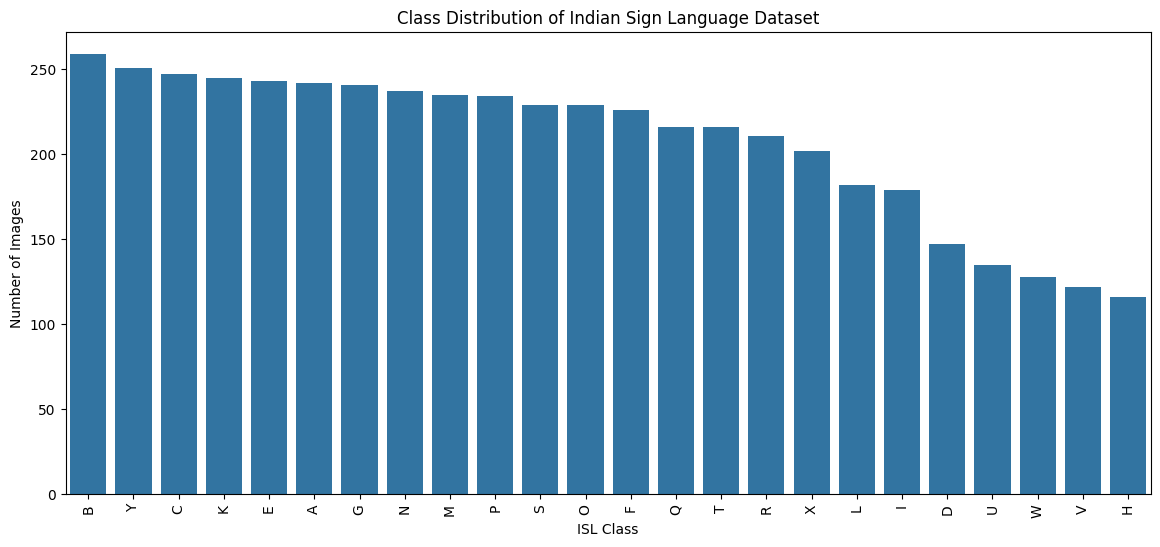

In [ ]:
plt.figure(figsize=(14, 6))

sns.barplot(
    x="Class",
    y="Image_Count",
    data=df_counts
)

plt.title("Class Distribution of Indian Sign Language Dataset")
plt.xlabel("ISL Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)

plt.show()

The class-distribution plot visually confirms that the dataset is moderately imbalanced. Most classes contain approximately 200–250 samples, whereas some classes such as H, V, W, U, and D contain fewer examples.

# Step 9: Visualize Sample Images

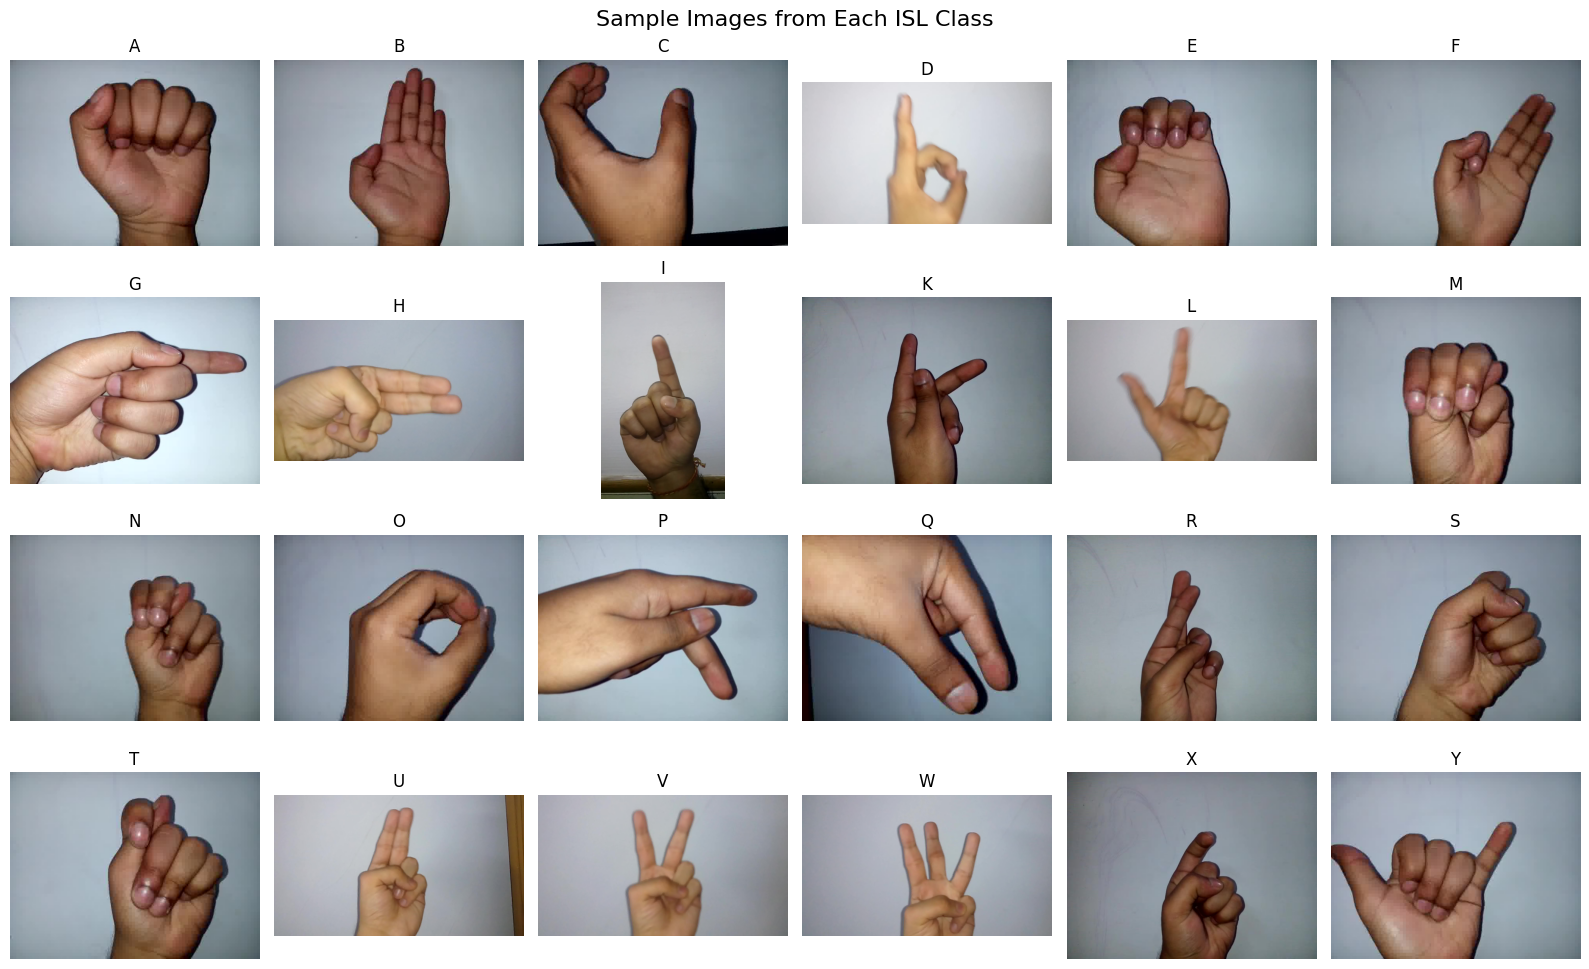

In [ ]:
plt.figure(figsize=(16, 10))

for i, class_name in enumerate(classes):

    class_folder = os.path.join(
        dataset_path,
        class_name
    )

    image_name = random.choice(
        os.listdir(class_folder)
    )

    image_path = os.path.join(
        class_folder,
        image_name
    )

    img = Image.open(image_path)

    plt.subplot(4, 6, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.suptitle(
    "Sample Images from Each ISL Class",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Image EDA

Sample images from every class were inspected to understand:

- differences in hand shapes and finger positions,
- gesture orientation,
- lighting conditions,
- background consistency,
- image quality,
- visual similarity between some sign classes.

This visual inspection helps identify challenges that may later appear during classification.

# Step 10: Analyze Image Dimensions

In [ ]:
widths = []
heights = []

for class_name in classes:

    class_folder = os.path.join(
        dataset_path,
        class_name
    )

    for image_name in os.listdir(class_folder):

        image_path = os.path.join(
            class_folder,
            image_name
        )

        img = Image.open(image_path)

        width, height = img.size

        widths.append(width)
        heights.append(height)

print("Minimum width:", min(widths))
print("Maximum width:", max(widths))
print("Minimum height:", min(heights))
print("Maximum height:", max(heights))

Minimum width: 640
Maximum width: 1920
Minimum height: 480
Maximum height: 1920


The dataset contains images with varying resolutions. Because CNN models require consistent input tensor dimensions, all images will later be resized to **128 × 128 pixels**.

# Step 11: Plot Image-Size Distribution

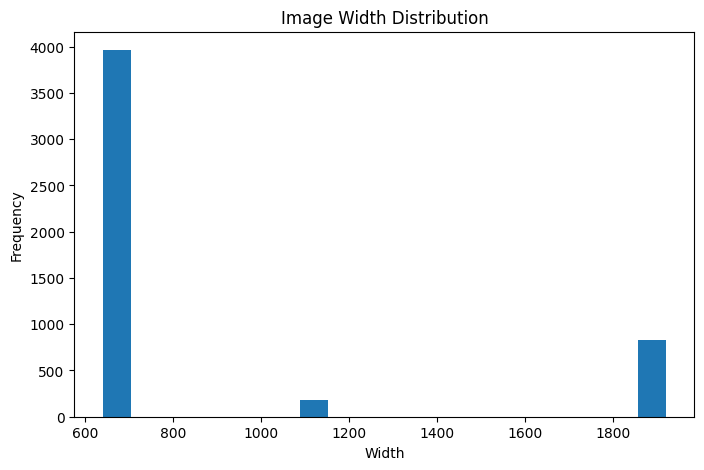

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(widths, bins=20)

plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")

plt.show()

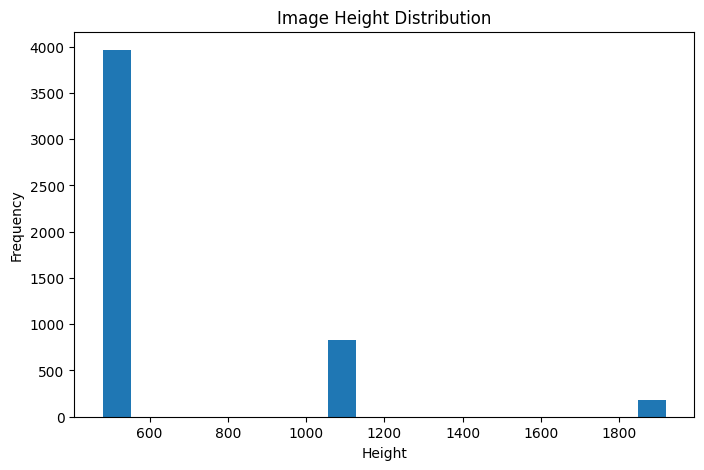

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(heights, bins=20)

plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")

plt.show()

# Step 12: Check Exact Duplicate Images in the Original Dataset

In [ ]:
from collections import defaultdict

hash_to_files = defaultdict(list)

for class_name in sorted(os.listdir(dataset_path)):

    class_folder = os.path.join(
        dataset_path,
        class_name
    )

    if not os.path.isdir(class_folder):
        continue

    for file_name in os.listdir(class_folder):

        if not file_name.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):
            continue

        file_path = os.path.join(
            class_folder,
            file_name
        )

        with open(file_path, "rb") as f:
            file_hash = hashlib.md5(
                f.read()
            ).hexdigest()

        hash_to_files[file_hash].append(
            file_path
        )

duplicate_groups = {
    file_hash: paths
    for file_hash, paths in hash_to_files.items()
    if len(paths) > 1
}

print(
    "Number of duplicate groups:",
    len(duplicate_groups)
)

print(
    "Number of extra duplicate files:",
    sum(
        len(paths) - 1
        for paths in duplicate_groups.values()
    )
)

Number of duplicate groups: 1
Number of extra duplicate files: 1


### Duplicate Analysis

An MD5 hash-based analysis was performed to identify exact duplicate image files.

One duplicate group containing one redundant image was detected.

MD5 hashing identifies exact file duplicates. It does not necessarily identify visually similar or near-duplicate images.

# Step 13: Create a Clean Dataset

In [ ]:
source_dir = "IndiSignLang/Data"
clean_dir = "IndiSignLang_Clean"

if os.path.exists(clean_dir):
    shutil.rmtree(clean_dir)

os.makedirs(
    clean_dir,
    exist_ok=True
)

seen_hashes = set()
removed_duplicates = []

for class_name in sorted(
    os.listdir(source_dir)
):

    class_source = os.path.join(
        source_dir,
        class_name
    )

    if not os.path.isdir(class_source):
        continue

    class_destination = os.path.join(
        clean_dir,
        class_name
    )

    os.makedirs(
        class_destination,
        exist_ok=True
    )

    for file_name in os.listdir(
        class_source
    ):

        if not file_name.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):
            continue

        source_path = os.path.join(
            class_source,
            file_name
        )

        with open(source_path, "rb") as f:
            file_hash = hashlib.md5(
                f.read()
            ).hexdigest()

        if file_hash not in seen_hashes:

            seen_hashes.add(file_hash)

            shutil.copy2(
                source_path,
                os.path.join(
                    class_destination,
                    file_name
                )
            )

        else:

            removed_duplicates.append(
                source_path
            )

print("Clean dataset created successfully.")
print(
    "Duplicates removed:",
    len(removed_duplicates)
)

for path in removed_duplicates:
    print("Removed:", path)

Clean dataset created successfully.
Duplicates removed: 1
Removed: IndiSignLang/Data/I/001.jpg


In [ ]:
total_clean_images = 0

for class_name in os.listdir(clean_dir):

    class_folder = os.path.join(
        clean_dir,
        class_name
    )

    if os.path.isdir(class_folder):

        total_clean_images += len(
            os.listdir(class_folder)
        )

print(
    "Total images after deduplication:",
    total_clean_images
)

Total images after deduplication: 4971


# Step 14: Create the Final 70:15:15 Split

In [ ]:
source_dir = "IndiSignLang_Clean"
split_dir = "ISL_Clean_Split"

train_dir = os.path.join(
    split_dir,
    "train"
)

val_dir = os.path.join(
    split_dir,
    "validation"
)

test_dir = os.path.join(
    split_dir,
    "test"
)

if os.path.exists(split_dir):
    shutil.rmtree(split_dir)

for folder in [
    train_dir,
    val_dir,
    test_dir
]:
    os.makedirs(
        folder,
        exist_ok=True
    )

classes = sorted(
    os.listdir(source_dir)
)

for class_name in classes:

    class_source = os.path.join(
        source_dir,
        class_name
    )

    if not os.path.isdir(class_source):
        continue

    image_names = [
        file_name
        for file_name in os.listdir(
            class_source
        )
        if file_name.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    train_images, temp_images = train_test_split(
        image_names,
        test_size=0.30,
        random_state=42
    )

    val_images, test_images = train_test_split(
        temp_images,
        test_size=0.50,
        random_state=42
    )

    for destination in [
        train_dir,
        val_dir,
        test_dir
    ]:

        os.makedirs(
            os.path.join(
                destination,
                class_name
            ),
            exist_ok=True
        )

    for image_name in train_images:

        shutil.copy2(
            os.path.join(
                class_source,
                image_name
            ),
            os.path.join(
                train_dir,
                class_name,
                image_name
            )
        )

    for image_name in val_images:

        shutil.copy2(
            os.path.join(
                class_source,
                image_name
            ),
            os.path.join(
                val_dir,
                class_name,
                image_name
            )
        )

    for image_name in test_images:

        shutil.copy2(
            os.path.join(
                class_source,
                image_name
            ),
            os.path.join(
                test_dir,
                class_name,
                image_name
            )
        )

print(
    "Clean 70:15:15 split created successfully."
)

Clean 70:15:15 split created successfully.


# Step 15: Verify the Final Split Counts

In [ ]:
def count_images(folder_path):

    total = 0

    for class_name in os.listdir(
        folder_path
    ):

        class_folder = os.path.join(
            folder_path,
            class_name
        )

        if os.path.isdir(class_folder):

            total += len(
                os.listdir(class_folder)
            )

    return total


print(
    "Training images:",
    count_images(train_dir)
)

print(
    "Validation images:",
    count_images(val_dir)
)

print(
    "Testing images:",
    count_images(test_dir)
)

Training images: 3468
Validation images: 743
Testing images: 760


# Step 16: Verify Zero Duplicate Leakage Across Final Train/Validation/Test Sets

## Data Leakage Verification After Final Dataset Split

After removing exact duplicate images and creating the final 70:15:15 train-validation-test split, an additional verification was performed to ensure that no identical image files were shared between the three subsets.

MD5 hashing was used to generate a unique hash for each image file. The hashes from the training, validation, and testing sets were then compared.

This verification is important because duplicate images appearing in different subsets can cause data leakage and produce overly optimistic validation or test performance.

In [ ]:
import os
import hashlib

def get_image_hashes(folder_path):

    hashes = {}

    for class_name in sorted(os.listdir(folder_path)):

        class_folder = os.path.join(
            folder_path,
            class_name
        )

        if not os.path.isdir(class_folder):
            continue

        for file_name in os.listdir(class_folder):

            if not file_name.lower().endswith(
                (".jpg", ".jpeg", ".png")
            ):
                continue

            file_path = os.path.join(
                class_folder,
                file_name
            )

            with open(file_path, "rb") as f:

                file_hash = hashlib.md5(
                    f.read()
                ).hexdigest()

            hashes[file_hash] = file_path

    return hashes


train_hashes = get_image_hashes(train_dir)
val_hashes = get_image_hashes(val_dir)
test_hashes = get_image_hashes(test_dir)


print("Training hashes:", len(train_hashes))
print("Validation hashes:", len(val_hashes))
print("Testing hashes:", len(test_hashes))

Training hashes: 3468
Validation hashes: 743
Testing hashes: 760


# Step 16.3: Compare the Three Sets

In [ ]:
train_val_duplicates = set(
    train_hashes.keys()
).intersection(
    val_hashes.keys()
)

train_test_duplicates = set(
    train_hashes.keys()
).intersection(
    test_hashes.keys()
)

val_test_duplicates = set(
    val_hashes.keys()
).intersection(
    test_hashes.keys()
)


print(
    "Train ↔ Validation duplicates:",
    len(train_val_duplicates)
)

print(
    "Train ↔ Test duplicates:",
    len(train_test_duplicates)
)

print(
    "Validation ↔ Test duplicates:",
    len(val_test_duplicates)
)

Train ↔ Validation duplicates: 0
Train ↔ Test duplicates: 0
Validation ↔ Test duplicates: 0


# Step 16.4: Add the Final Verification Statement

### Data Leakage Verification Result

The final cleaned dataset contained **4,971 unique images** and was divided into approximately **70:15:15 training, validation, and testing subsets**:

- **Training set:** 3,468 images
- **Validation set:** 743 images
- **Testing set:** 760 images

MD5-based duplicate verification produced the following results:

- **Train ↔ Validation duplicates:** 0
- **Train ↔ Test duplicates:** 0
- **Validation ↔ Test duplicates:** 0

Therefore, no exact duplicate image files were shared across the final training, validation, and testing subsets.

This reduces the risk of exact-file data leakage and provides a more reliable basis for model training and evaluation.

**Limitation:** MD5 hashing detects exact file duplicates. It does not necessarily identify visually similar or near-duplicate images.

# Step 17: Save the Clean Dataset and Split to Google Drive

## Save the Clean Dataset to Google Drive

The cleaned dataset and final train-validation-test split are saved to Google Drive to preserve the processed data beyond the temporary Colab runtime.

Saving the cleaned dataset also ensures that subsequent model-development experiments use exactly the same verified dataset split.

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


# Step 17.3: Create the Project Folder

In [ ]:
project_folder = "/content/drive/MyDrive/ISL_Project"

os.makedirs(
    project_folder,
    exist_ok=True
)

print("Project folder:")
print(project_folder)

Project folder:
/content/drive/MyDrive/ISL_Project


# Step 17.4: Save the Clean Dataset

In [ ]:
clean_destination = os.path.join(
    project_folder,
    "IndiSignLang_Clean"
)

if os.path.exists(clean_destination):
    shutil.rmtree(clean_destination)

shutil.copytree(
    clean_dir,
    clean_destination
)

print(
    "Clean dataset saved successfully."
)

Clean dataset saved successfully.


# Step 17.5: Save the Final 70:15:15 Split

In [ ]:
split_destination = os.path.join(
    project_folder,
    "ISL_Clean_Split"
)

if os.path.exists(split_destination):
    shutil.rmtree(split_destination)

shutil.copytree(
    split_dir,
    split_destination
)

print(
    "Clean 70:15:15 split saved successfully."
)

Clean 70:15:15 split saved successfully.


# Step 17.6: Verify That Everything Was Saved

In [ ]:
print(
    "Clean dataset saved:",
    os.path.exists(clean_destination)
)

print(
    "Clean split saved:",
    os.path.exists(split_destination)
)

print(
    "Train saved:",
    os.path.exists(
        os.path.join(
            split_destination,
            "train"
        )
    )
)

print(
    "Validation saved:",
    os.path.exists(
        os.path.join(
            split_destination,
            "validation"
        )
    )
)

print(
    "Test saved:",
    os.path.exists(
        os.path.join(
            split_destination,
            "test"
        )
    )
)

Clean dataset saved: True
Clean split saved: True
Train saved: True
Validation saved: True
Test saved: True


### Dataset Preservation

The cleaned dataset and final 70:15:15 split were successfully saved to Google Drive.

The saved split contains separate training, validation, and testing directories and will be reused throughout model development. This ensures that all models are trained and evaluated using the same data partitions, allowing a fair comparison between model architectures.

# Step 18: Connect Model Development to the Saved Clean Split

# Final Model Development Using the Clean Dataset

Following dataset cleaning, duplicate removal, split creation, and leakage verification, the final model-development stage was performed using the saved clean dataset.

Two deep-learning approaches are evaluated:

1. **Baseline CNN trained from scratch**
2. **MobileNetV2 using transfer learning**

Both models use the same training, validation, and testing subsets to ensure a fair comparison.

## Connect to the Saved Clean Dataset

In [ ]:
split_dir = "/content/drive/MyDrive/ISL_Project/ISL_Clean_Split"

train_dir = os.path.join(
    split_dir,
    "train"
)

val_dir = os.path.join(
    split_dir,
    "validation"
)

test_dir = os.path.join(
    split_dir,
    "test"
)


print(
    "Train exists:",
    os.path.exists(train_dir)
)

print(
    "Validation exists:",
    os.path.exists(val_dir)
)

print(
    "Test exists:",
    os.path.exists(test_dir)
)

Train exists: True
Validation exists: True
Test exists: True


# Step 19: Create ImageDataGenerators for the Baseline CNN

## Image Preprocessing and Data Augmentation

All images are resized to **128 × 128 pixels**.

For the baseline CNN, pixel values are normalized from their original 0–255 range to approximately 0–1 using a rescaling factor of `1/255`.

Data augmentation is applied only to the training set to increase image variation and reduce overfitting. Small rotations, zooms, translations, and shear transformations are used.

Horizontal flipping is intentionally disabled because flipping a hand gesture can potentially alter the semantic or spatial characteristics of a sign.

The validation and testing sets are not augmented because they should represent unchanged evaluation data.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 128
batch_size = 32


# Training: normalization + augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=False,
    fill_mode='nearest'
)


# Validation and Test: normalization only
eval_datagen = ImageDataGenerator(
    rescale=1./255
)


train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)


val_data = eval_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


test_data = eval_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 3468 images belonging to 24 classes.
Found 743 images belonging to 24 classes.
Found 760 images belonging to 24 classes.


# Step 20: Build the Clean Baseline CNN From Scratch

## Clean Baseline CNN

A baseline Convolutional Neural Network (CNN) was developed from scratch using the cleaned training dataset.

The purpose of the baseline model is to establish a reference performance before applying transfer learning.

The CNN consists of three convolutional blocks for hierarchical feature extraction, followed by a fully connected classification stage.

The number of filters progressively increases from 32 to 64 to 128, allowing the network to learn increasingly complex visual patterns.

Max-pooling layers reduce the spatial dimensions of the feature maps, while a dropout layer is used to reduce overfitting.

The final output layer contains 24 neurons with softmax activation, corresponding to the 24 Indian Sign Language classes.

# Step 20.2 — Create the CNN

In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)


clean_baseline_model = Sequential([

    # Input layer
    Input(shape=(128, 128, 3)),

    # Convolution Block 1
    Conv2D(
        32,
        (3, 3),
        activation='relu'
    ),

    MaxPooling2D(
        (2, 2)
    ),

    # Convolution Block 2
    Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    MaxPooling2D(
        (2, 2)
    ),

    # Convolution Block 3
    Conv2D(
        128,
        (3, 3),
        activation='relu'
    ),

    MaxPooling2D(
        (2, 2)
    ),

    # Convert feature maps into a 1D vector
    Flatten(),

    # Fully connected layer
    Dense(
        128,
        activation='relu'
    ),

    # Regularization
    Dropout(0.4),

    # Output layer: 24 ISL classes
    Dense(
        24,
        activation='softmax'
    )

])


clean_baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,307,736 (12.62 MB)

 Trainable params: 3,307,736 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

# Step 21: Compile the Baseline CNN

## Model Compilation

The baseline CNN was compiled using the Adam optimizer and categorical cross-entropy loss.

**Adam** was selected because it adaptively adjusts the optimization process and is widely used for training deep neural networks.

**Categorical cross-entropy** was selected because this is a multi-class classification problem containing 24 mutually exclusive ISL classes, with labels represented using one-hot encoding by the image generator.

**Accuracy** was used as a training metric to measure the proportion of correctly classified images.

In [ ]:
clean_baseline_model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)


print(
    "Clean baseline CNN compiled successfully."
)

Clean baseline CNN compiled successfully.


# Step 22: Create Training Callbacks

## Training Callbacks

Three callbacks were incorporated to improve training stability and model selection.

### EarlyStopping
Training is stopped if validation loss fails to improve for five consecutive epochs. The best model weights observed during training are restored.

### ReduceLROnPlateau
If validation loss stops improving for two epochs, the learning rate is reduced by a factor of 0.5. Smaller learning rates can help the optimizer make finer weight adjustments as training approaches convergence.

### ModelCheckpoint
The model producing the lowest validation loss is automatically saved to Google Drive.

Validation loss was selected as the monitoring criterion because it reflects both prediction correctness and confidence on data not used for weight updates.

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)


clean_callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),

    ModelCheckpoint(
        '/content/drive/MyDrive/ISL_Project/best_clean_baseline_model.keras',
        monitor='val_loss',
        save_best_only=True
    )

]


print(
    "Clean baseline callbacks created successfully."
)

Clean baseline callbacks created successfully.


# Step 23: Train the Clean Baseline CNN

## Baseline CNN Training

The clean baseline CNN was trained using the augmented training dataset and evaluated after each epoch using the independent validation set.

A maximum of 25 epochs was specified. Early stopping was enabled so that training could terminate automatically if validation loss stopped improving.

The validation dataset is used only for monitoring model performance and model selection; it is not used for gradient-based weight updates.

In [ ]:
!nvidia-smi

Tue Aug 11 13:06:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P0             32W /   70W |     173MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Step 23.3 — Train the Model

In [ ]:
history_clean = clean_baseline_model.fit(

    train_data,

    validation_data=val_data,

    epochs=25,

    callbacks=clean_callbacks

)

Epoch 1/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 53s 419ms/step - accuracy: 0.2166 - loss: 2.6681 - val_accuracy: 0.6433 - val_loss: 1.2623 - learning_rate: 0.0010
Epoch 2/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 35s 323ms/step - accuracy: 0.5087 - loss: 1.5972 - val_accuracy: 0.8600 - val_loss: 0.6040 - learning_rate: 0.0010
Epoch 3/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 35s 320ms/step - accuracy: 0.6315 - loss: 1.1289 - val_accuracy: 0.9314 - val_loss: 0.3125 - learning_rate: 0.0010
Epoch 4/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 34s 315ms/step - accuracy: 0.7096 - loss: 0.8651 - val_accuracy: 0.9273 - val_loss: 0.2394 - learning_rate: 0.0010
Epoch 5/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 36s 331ms/step - accuracy: 0.7569 - loss: 0.7290 - val_accuracy: 0.9394 - val_loss: 0.2202 - learning_rate: 0.0010
Epoch 6/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 35s 317ms/step - accuracy: 0.8036 - loss: 0.5990 - val_accuracy: 0.9650 - val_loss: 0.1374 - learning_rate: 0.0010
Epoch 7/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 35s 325ms/step - accuracy: 0.8

# Step 24: Identify the Best Baseline Epoch

## Best Baseline CNN Epoch

The best training epoch was identified using the minimum validation loss.

Validation loss was selected because it reflects both classification correctness and prediction confidence on data not used for model weight updates.

In [ ]:
import numpy as np

val_losses = history_clean.history['val_loss']
val_accuracies = history_clean.history['val_accuracy']

best_epoch = np.argmin(val_losses) + 1

print("Best Epoch:", best_epoch)

print(
    "Best Validation Loss:",
    val_losses[best_epoch - 1]
)

print(
    "Validation Accuracy at Best Epoch:",
    val_accuracies[best_epoch - 1]
)

Best Epoch: 25
Best Validation Loss: 0.010595371015369892
Validation Accuracy at Best Epoch: 0.9973081946372986


### Best Epoch Analysis

The minimum validation loss was achieved at **epoch 25**, with a validation loss of **0.0106** and a validation accuracy of **99.73%**.

Since the lowest validation loss occurred at the final epoch, the final trained model also represents the best-performing checkpoint according to the selected validation-loss criterion.

# Step 25: Plot Training and Validation Accuracy

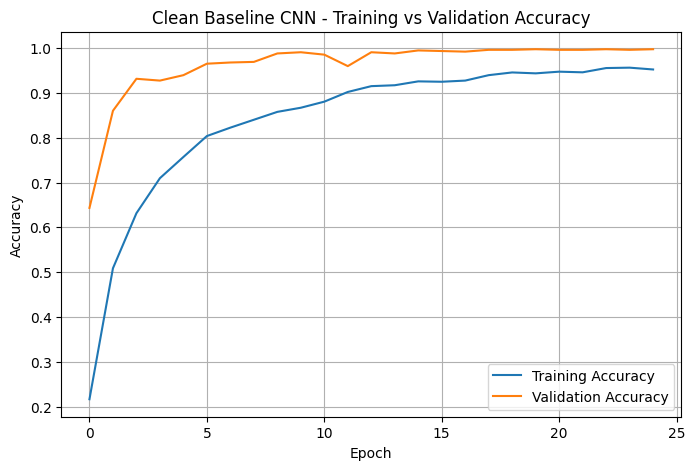

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_clean.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_clean.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title(
    'Clean Baseline CNN - Training vs Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

# Step 26: Plot Training and Validation Loss

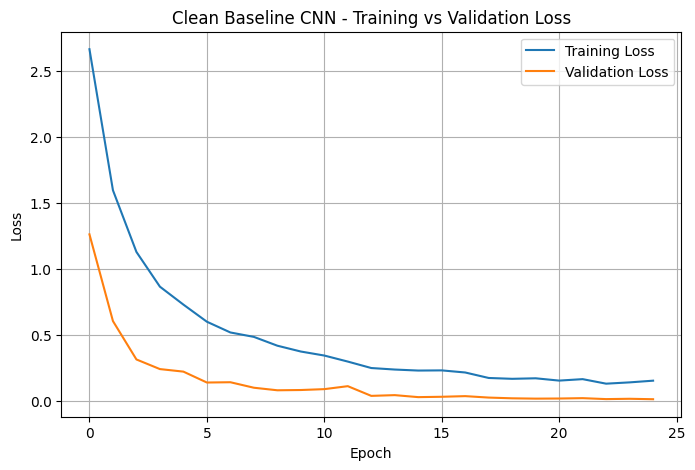

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_clean.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_clean.history['val_loss'],
    label='Validation Loss'
)

plt.title(
    'Clean Baseline CNN - Training vs Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

# Step 25–26: Interpretation for your Colab report

### Clean Baseline CNN Training Curve Analysis

The training and validation curves demonstrate strong and stable learning behavior across the 25 epochs.

Training accuracy increased progressively throughout training, reaching approximately **95.21%**, while validation accuracy reached **99.73%** at the final epoch. The validation accuracy remained consistently high during the later epochs, indicating strong performance on the validation dataset.

Similarly, training loss decreased substantially from the initial epochs to approximately **0.1514**, while validation loss decreased to its minimum value of **0.0106 at epoch 25**. Although minor fluctuations were observed in validation performance during training, there was no sustained increase in validation loss toward the end of training.

Validation performance remained higher than training performance. This is reasonable because data augmentation was applied to the training images, making them more challenging, and Dropout (0.4) was active during training but disabled during validation.

Overall, the learning curves indicate effective convergence without a clear pattern of severe overfitting. However, final generalization performance must be determined using the independent test set, which was not used for model training or model selection.

# Step 27: Evaluate Clean Baseline CNN on Independent Test Set

## Clean Baseline CNN - Independent Test Evaluation

After completing model training and validation, the clean baseline CNN was evaluated on the held-out test set.

The test set contained **760 images across 24 ISL classes** and was not used for model weight updates. Evaluating on this independent subset provides a more objective estimate of the model's generalization performance on unseen samples from the same dataset.

In [ ]:
# Reset the test generator before evaluation
test_data.reset()

# Evaluate the clean baseline CNN
test_loss, test_accuracy = clean_baseline_model.evaluate(
    test_data,
    verbose=1
)

print("\nClean Baseline CNN Test Results")
print("--------------------------------")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 241ms/step - accuracy: 0.9987 - loss: 0.0102

Clean Baseline CNN Test Results
--------------------------------
Test Loss: 0.010173751972615719
Test Accuracy: 0.9986842274665833
Test Accuracy (%): 99.86842274665833


### Clean Baseline CNN Test Performance

The clean baseline CNN was evaluated on the independent test set containing **760 images across 24 ISL classes**.

The model achieved a **test accuracy of 99.87%** with a low **test loss of 0.0102**, demonstrating excellent classification performance on the held-out test subset.

The test accuracy was also very close to the best validation accuracy of **99.73%**, indicating consistent performance between the validation and test subsets. This provides evidence that the model learned discriminative features for the 24 ISL classes without showing a large validation-to-test performance drop.

However, these results represent performance on the held-out subset of the current dataset. Further evaluation using independently collected real-world images is required to assess generalization across different users, backgrounds, lighting conditions, camera devices, and hand orientations.

# Step 28: Classification Report

## Classification Report - Clean Baseline CNN

To evaluate class-wise performance, precision, recall, F1-score, and support were calculated for each of the 24 ISL classes.

This analysis is particularly important because overall accuracy alone may hide poor performance for individual classes, especially when class frequencies are not perfectly balanced.

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Start prediction from the beginning of the test dataset
test_data.reset()

# Generate class probabilities for all test images
y_prob = clean_baseline_model.predict(
    test_data,
    verbose=1
)

# Convert probabilities into predicted class indices
y_pred = np.argmax(
    y_prob,
    axis=1
)

# True class indices
y_true = test_data.classes

# Get class names in their correct index order
class_names = list(
    test_data.class_indices.keys()
)

# Display classification report
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 193ms/step
              precision    recall  f1-score   support

           A     1.0000    1.0000    1.0000        37
           B     1.0000    0.9744    0.9870        39
           C     1.0000    1.0000    1.0000        38
           D     1.0000    1.0000    1.0000        23
           E     0.9737    1.0000    0.9867        37
           F     1.0000    1.0000    1.0000        34
           G     1.0000    1.0000    1.0000        37
           H     1.0000    1.0000    1.0000        18
           I     1.0000    1.0000    1.0000        27
           K     1.0000    1.0000    1.0000        37
           L     1.0000    1.0000    1.0000        28
           M     1.0000    1.0000    1.0000        36
           N     1.0000    1.0000    1.0000        36
           O     1.0000    1.0000    1.0000        35
           P     1.0000    1.0000    1.0000        36
           Q     1.0000    1.0000    1.0000        33
           R     1.0000    1.0000    1.0

### Classification Report Analysis

The clean baseline CNN achieved an overall test accuracy of **99.87%** on the 760-image held-out test set. The macro-average precision, recall, and F1-score were approximately **99.89%**, while the weighted-average F1-score was approximately **99.87%**, demonstrating highly consistent performance across the 24 ISL classes.

Twenty-two of the 24 classes achieved perfect precision, recall, and F1-score values of **1.0000** on the current test split.

Class **B** achieved a precision of **1.0000**, recall of **0.9744**, and F1-score of **0.9870**. This indicates that 38 of the 39 actual B samples were correctly classified, while one B sample was assigned to another class.

Class **E** achieved a recall of **1.0000** and precision of **0.9737**, indicating that all 37 actual E samples were correctly identified, but one sample from another class was incorrectly predicted as E.

Overall, only **1 of the 760 test images was misclassified**. The strong macro-average scores indicate that the high overall accuracy was not driven solely by the more frequent classes. The exact misclassification pattern was subsequently examined using a confusion matrix.

# Step 29: Confusion Matrix — Clean Baseline CNN

## Confusion Matrix - Clean Baseline CNN

A confusion matrix was generated to examine the exact class-level prediction pattern of the clean baseline CNN.

Values along the main diagonal represent correctly classified images, while off-diagonal values represent misclassifications between different ISL classes.

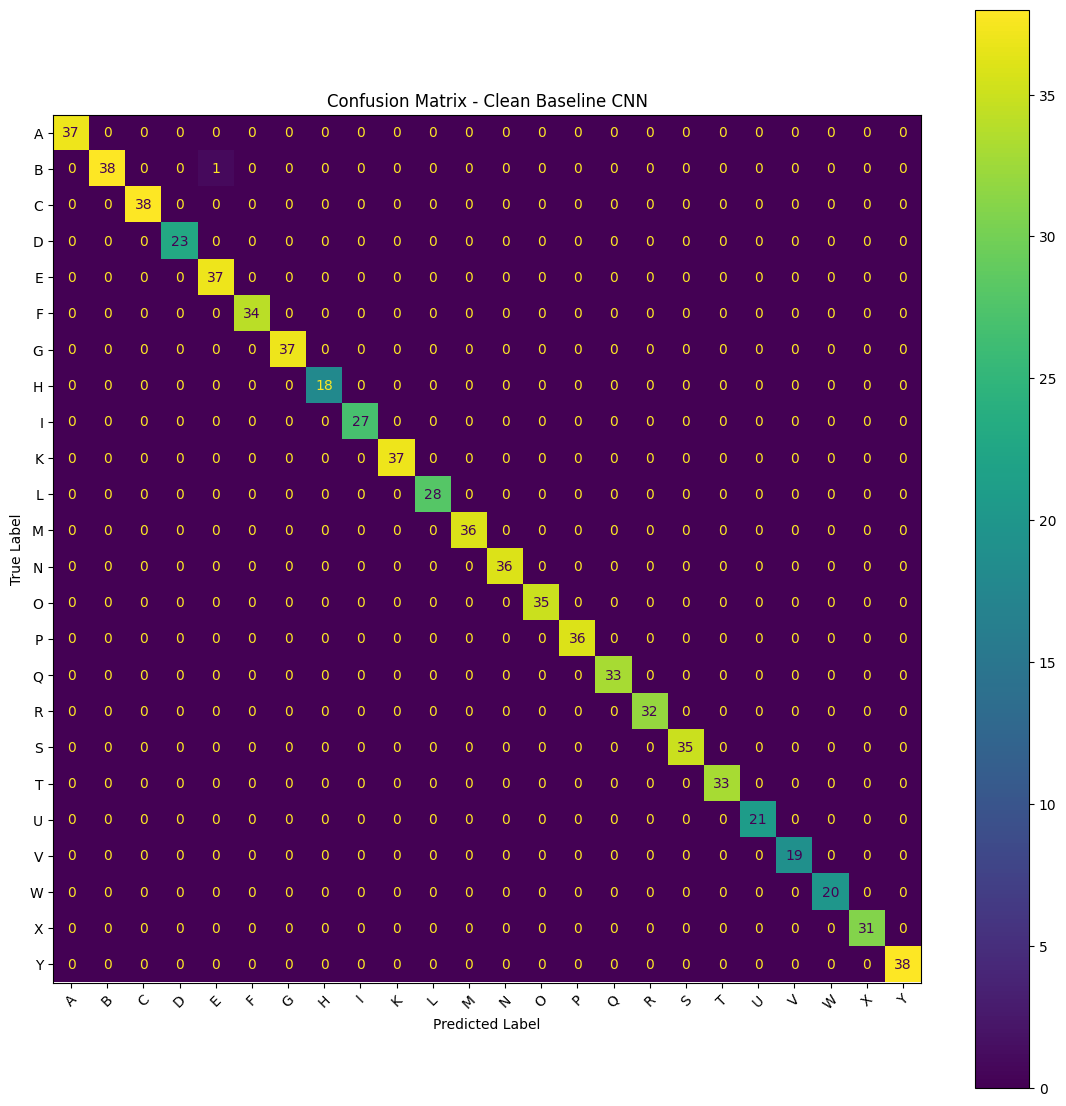

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

# Display confusion matrix
fig, ax = plt.subplots(figsize=(14, 14))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format='d'
)

plt.title(
    'Confusion Matrix - Clean Baseline CNN'
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

### Confusion Matrix Analysis

The confusion matrix confirms the strong performance of the clean baseline CNN on the held-out test set.

Out of **760 test images, 759 were correctly classified and only one image was misclassified**. Almost all predictions are located along the main diagonal, indicating correct classification across the 24 ISL classes.

The only error occurred for class **B**. Of the 39 actual B test images, **38 were correctly classified as B**, while **one B image was incorrectly predicted as E**. All 37 actual E images were correctly classified as E; however, the additional B-to-E prediction reduced the precision of class E to **97.37%**.

All remaining 22 classes achieved perfect classification on the current test split, with no off-diagonal errors.

The confusion matrix therefore confirms the classification-report findings and demonstrates excellent performance of the baseline CNN on the internal held-out test set. However, evaluation on independently collected external images is still necessary to assess real-world generalization.

# Step 30: Identify the Misclassified Image

## Misclassification Analysis - Clean Baseline CNN

To better understand the model's remaining error, the incorrectly classified test sample was identified and visually inspected.

Examining individual errors helps determine whether misclassification may be associated with visual similarity between signs, hand orientation, image quality, background variation, or model uncertainty.

In [ ]:
# Find indices where prediction != actual label

misclassified_indices = np.where(
    y_pred != y_true
)[0]

print(
    "Number of misclassified images:",
    len(misclassified_indices)
)

print(
    "Misclassified indices:",
    misclassified_indices
)

Number of misclassified images: 1
Misclassified indices: [60]


# Step 31: Display the Misclassified Image

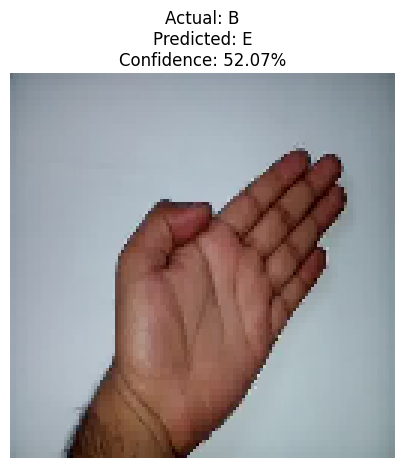

Image path: /content/drive/MyDrive/ISL_Project/ISL_Clean_Split/test/B/132.jpg
Actual class: B
Predicted class: E
Prediction confidence: 52.07%


In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img

# Create index-to-class mapping
index_to_class = {
    v: k
    for k, v in test_data.class_indices.items()
}

# Get the misclassified image index
idx = misclassified_indices[0]

# Get its file path
image_path = test_data.filepaths[idx]

# Load image for display
img = load_img(
    image_path,
    target_size=(128, 128)
)

# Actual class
actual_class = index_to_class[
    y_true[idx]
]

# Predicted class
predicted_class = index_to_class[
    y_pred[idx]
]

# Confidence of predicted class
confidence = (
    y_prob[idx][y_pred[idx]] * 100
)

# Display image
plt.figure(figsize=(5, 5))

plt.imshow(img)

plt.title(
    f"Actual: {actual_class}\n"
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")
plt.show()

print("Image path:", image_path)
print("Actual class:", actual_class)
print("Predicted class:", predicted_class)
print(
    "Prediction confidence:",
    f"{confidence:.2f}%"
)

### Misclassification Analysis

The clean baseline CNN misclassified only **1 out of 760 test images**. The misclassified sample belonged to class **B** but was predicted as class **E**, with a prediction confidence of **52.07%**.

Visual inspection of the image shows a particular hand orientation and finger configuration that may have produced features that the baseline CNN associated more strongly with class E. The relatively moderate prediction confidence of 52.07% indicates that the model was not strongly certain about the incorrect prediction.

This error is consistent with the classification report and confusion matrix: class B achieved a recall of **97.44%**, while class E achieved a precision of **97.37%** because it received one false-positive prediction from class B.

Overall, the baseline CNN correctly classified **759 of the 760 test images**, demonstrating excellent performance on the held-out internal test set. However, analysis of the remaining error highlights the importance of evaluating the model on more diverse external images containing variations in users, hand orientation, lighting, background, and image-acquisition conditions.

# Step 32: Save the Final Clean Baseline CNN

In [ ]:
final_baseline_path = (
    "/content/drive/MyDrive/ISL_Project/"
    "final_clean_baseline_cnn.keras"
)

clean_baseline_model.save(
    final_baseline_path
)

print("Clean baseline CNN saved successfully!")
print("Saved at:", final_baseline_path)

Clean baseline CNN saved successfully!
Saved at: /content/drive/MyDrive/ISL_Project/final_clean_baseline_cnn.keras


# Step 33: Final Baseline CNN Summary

## Clean Baseline CNN - Final Results

The clean baseline CNN was trained from scratch using the refined 70:15:15 dataset split containing **3,468 training images, 743 validation images, and 760 test images across 24 ISL classes**.

The best validation performance was obtained at **epoch 25**, with a validation accuracy of **99.73%** and validation loss of **0.0106**.

On the independent held-out test set, the model achieved:

- **Test Accuracy:** 99.87%
- **Test Loss:** 0.0102
- **Macro Precision:** 99.89%
- **Macro Recall:** 99.89%
- **Macro F1-score:** 99.89%
- **Weighted F1-score:** 99.87%
- **Correct Predictions:** 759 / 760
- **Misclassified Images:** 1 / 760

The only observed test error involved an actual **B** image that was predicted as **E** with **52.07% confidence**.

These results establish a strong CNN-from-scratch baseline for subsequent comparison with a pretrained transfer-learning architecture. Because the evaluation was performed on an internal held-out subset from the same source dataset, external testing remains necessary before making conclusions about real-world generalization.

# Step 34: Introduce MobileNetV2 Transfer Learning

# MobileNetV2 Transfer Learning

To determine whether pretrained visual features could improve performance over the CNN trained from scratch, a MobileNetV2 transfer-learning model was developed.

MobileNetV2 is a lightweight convolutional neural network pretrained on the ImageNet dataset.

Instead of learning all visual features from scratch, the pretrained MobileNetV2 convolutional base is reused as a feature extractor.

For the first stage of transfer learning:

- the pretrained MobileNetV2 base is loaded,
- the original ImageNet classifier is removed,
- the pretrained feature extractor is frozen,
- a new classification head is added for the 24 ISL classes.

This approach reduces the number of trainable parameters and allows the model to benefit from general visual features learned from a much larger image dataset.

# Step 35: Create MobileNetV2-Specific Data Generators

## MobileNetV2-Specific Image Preprocessing

The MobileNetV2 model uses its architecture-specific `preprocess_input` function rather than simple 0–1 normalization.

For MobileNetV2, this preprocessing transforms input pixel values to approximately the range **[-1, 1]**, matching the representation expected by the pretrained ImageNet weights.

The same clean training, validation, and testing subsets are retained so that the MobileNetV2 model can be compared fairly with the baseline CNN.

Data augmentation is applied only to the training images.

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator


mobilenet_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=False,
    fill_mode='nearest'
)


mobilenet_eval_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


mobilenet_train_data = mobilenet_train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)


mobilenet_val_data = mobilenet_eval_datagen.flow_from_directory(
    val_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


mobilenet_test_data = mobilenet_eval_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3468 images belonging to 24 classes.
Found 743 images belonging to 24 classes.
Found 760 images belonging to 24 classes.


# Step 36: Load the Pretrained MobileNetV2 Base

## Load the Pretrained MobileNetV2 Feature Extractor

The MobileNetV2 convolutional base was initialized using weights pretrained on ImageNet.

`include_top=False` removes the original ImageNet classification layer because the current task requires classification into 24 Indian Sign Language classes rather than the original ImageNet categories.

The pretrained convolutional base is initially frozen so that its learned weights are preserved during the first transfer-learning stage.

In [ ]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

base_model.trainable = False

print("MobileNetV2 pretrained base loaded successfully.")
print("Base model trainable:", base_model.trainable)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 pretrained base loaded successfully.
Base model trainable: False


# Step 37: Add the ISL Classification Head

## Add the ISL-Specific Classification Head

The frozen MobileNetV2 feature extractor produces high-level convolutional feature maps.

GlobalAveragePooling2D is used to summarize these feature maps into a compact feature vector.

A fully connected layer with 128 ReLU units is then added, followed by Dropout with a rate of 0.4 for regularization.

The final Softmax layer contains 24 neurons corresponding to the 24 ISL classes.

In [ ]:
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.models import Model


inputs = Input(
    shape=(128, 128, 3)
)

x = base_model(
    inputs,
    training=False
)

x = GlobalAveragePooling2D()(x)

x = Dense(
    128,
    activation='relu'
)(x)

x = Dropout(0.4)(x)

outputs = Dense(
    24,
    activation='softmax'
)(x)


mobilenet_model = Model(
    inputs,
    outputs
)

mobilenet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,425,048 (9.25 MB)

 Trainable params: 167,064 (652.59 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Step 39: Compile MobileNetV2

## MobileNetV2 Compilation

The MobileNetV2 transfer-learning model was compiled using the Adam optimizer, categorical cross-entropy loss, and accuracy as the training metric.

Categorical cross-entropy is appropriate because the model predicts one of 24 mutually exclusive ISL classes using one-hot encoded labels.

In [ ]:
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(
    "MobileNetV2 model compiled successfully."
)

MobileNetV2 model compiled successfully.


# Step 40: Create MobileNetV2 Callbacks

## MobileNetV2 Training Callbacks

The same validation-loss-based training strategy used for the baseline CNN was applied to MobileNetV2.

- **EarlyStopping** stops training if validation loss fails to improve.
- **ReduceLROnPlateau** lowers the learning rate when improvement slows.
- **ModelCheckpoint** saves the best MobileNetV2 model according to validation loss.

Using the same callback strategy supports a fairer comparison between the two architectures.

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)


mobilenet_callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),

    ModelCheckpoint(
        '/content/drive/MyDrive/ISL_Project/best_mobilenetv2_model.keras',
        monitor='val_loss',
        save_best_only=True
    )

]


print(
    "MobileNetV2 callbacks created successfully."
)

MobileNetV2 callbacks created successfully.


# Step 41: Train the Frozen MobileNetV2 Model

## MobileNetV2 Stage 1 Training

In the first transfer-learning stage, the pretrained MobileNetV2 convolutional base remains frozen.

Only the newly added ISL-specific classification layers are optimized.

The model is trained for a maximum of 20 epochs while validation loss is monitored through the training callbacks.

In [ ]:
history_mobilenet = mobilenet_model.fit(
    mobilenet_train_data,
    validation_data=mobilenet_val_data,
    epochs=20,
    callbacks=mobilenet_callbacks
)

Epoch 1/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 96s 634ms/step - accuracy: 0.6589 - loss: 1.2283 - val_accuracy: 0.9381 - val_loss: 0.2416 - learning_rate: 0.0010
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 37s 341ms/step - accuracy: 0.9201 - loss: 0.2961 - val_accuracy: 0.9892 - val_loss: 0.0747 - learning_rate: 0.0010
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 36s 332ms/step - accuracy: 0.9550 - loss: 0.1649 - val_accuracy: 0.9906 - val_loss: 0.0396 - learning_rate: 0.0010
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 37s 336ms/step - accuracy: 0.9694 - loss: 0.1200 - val_accuracy: 0.9852 - val_loss: 0.0426 - learning_rate: 0.0010
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 41s 373ms/step - accuracy: 0.9700 - loss: 0.1104 - val_accuracy: 0.9933 - val_loss: 0.0227 - learning_rate: 0.0010
Epoch 6/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 36s 332ms/step - accuracy: 0.9749 - loss: 0.0843 - val_accuracy: 0.9933 - val_loss: 0.0284 - learning_rate: 0.0010
Epoch 7/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 38s 347ms/step - accuracy: 0.9

### Early Stopping Observation

Although a maximum of 20 epochs was specified, MobileNetV2 training stopped automatically after 15 epochs because the EarlyStopping callback detected that validation loss had stopped improving for the configured patience period.

Since `restore_best_weights=True` was used, the model weights were restored to those from the epoch that achieved the lowest validation loss.

Therefore, early termination does not indicate a training failure; it indicates that the model had already reached its best validation performance and additional epochs were not expected to provide meaningful improvement.

# Step 42: verifying the exact best epoch

In [ ]:
import numpy as np

mobilenet_val_losses = history_mobilenet.history['val_loss']
mobilenet_val_accuracies = history_mobilenet.history['val_accuracy']

best_mobilenet_epoch = np.argmin(mobilenet_val_losses) + 1

print("Best MobileNetV2 Epoch:", best_mobilenet_epoch)
print(
    "Best Validation Loss:",
    mobilenet_val_losses[best_mobilenet_epoch - 1]
)
print(
    "Validation Accuracy at Best Epoch:",
    mobilenet_val_accuracies[best_mobilenet_epoch - 1]
)

Best MobileNetV2 Epoch: 10
Best Validation Loss: 0.007530889008194208
Validation Accuracy at Best Epoch: 0.9986541271209717


### Best MobileNetV2 Epoch Analysis

The best MobileNetV2 performance was obtained at **epoch 10**, where the validation loss reached its minimum value of **0.0075** and the validation accuracy reached approximately **99.87%**.

Although training continued until epoch 15, the validation loss after epoch 10 did not improve beyond the minimum obtained at epoch 10. After five consecutive epochs without a new minimum validation loss, the EarlyStopping callback terminated training.

Because `restore_best_weights=True` was enabled, the model automatically restored the weights from the best-performing epoch rather than retaining the weights from the final epoch.

This demonstrates the usefulness of early stopping in preventing unnecessary training and preserving the model configuration that generalized best to the validation set.

# Step 43: Plot MobileNetV2 Training and Validation Accuracy

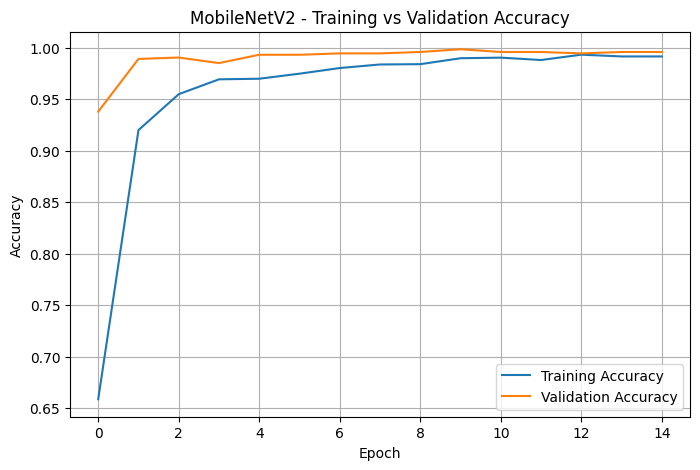

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_mobilenet.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_mobilenet.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title(
    'MobileNetV2 - Training vs Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

### MobileNetV2 Accuracy Curve Interpretation

The training accuracy increased rapidly during the first few epochs, demonstrating fast convergence of the transfer-learning model.

Validation accuracy also remained very high throughout training, reaching approximately **99.87%** at the best epoch.

The small gap between the training and validation accuracy curves toward the later epochs indicates that the model learned stable discriminative features for the ISL classes.

The high validation accuracy from the early stages of training also suggests that the pretrained ImageNet features transferred effectively to the current sign-language classification task.

# Step 44: Plot MobileNetV2 Training and Validation Loss

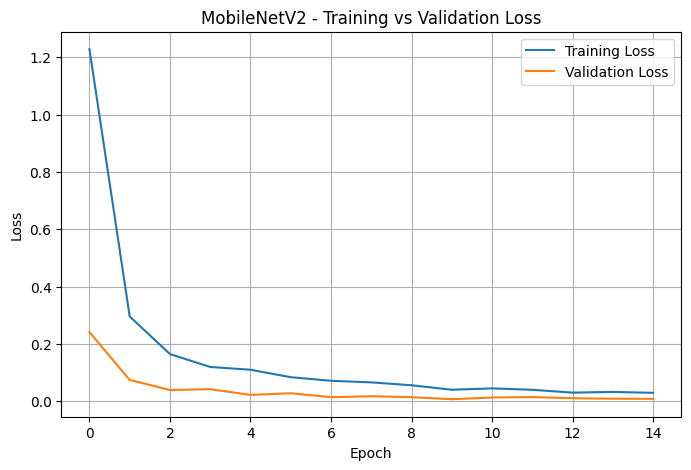

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_mobilenet.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_mobilenet.history['val_loss'],
    label='Validation Loss'
)

plt.title(
    'MobileNetV2 - Training vs Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

### MobileNetV2 Loss Curve Interpretation

Both training loss and validation loss decreased substantially during training.

The minimum validation loss of **0.0075** occurred at epoch 10. After this point, validation loss fluctuated slightly but did not improve beyond the best value.

The absence of a sustained increase in validation loss suggests that there was no clear pattern of severe overfitting during the frozen transfer-learning stage.

The EarlyStopping callback correctly terminated training after the validation loss failed to improve for five consecutive epochs.

# Step 45: Evaluate MobileNetV2 on the Independent Test Set

## MobileNetV2 - Independent Test Evaluation

After training and automatic restoration of the best validation weights, MobileNetV2 was evaluated on the held-out test set containing **760 images across 24 ISL classes**.

The test set was not used for model training or validation-based model selection, making it suitable for final internal performance evaluation.

In [ ]:
mobilenet_test_data.reset()

mobilenet_test_loss, mobilenet_test_accuracy = mobilenet_model.evaluate(
    mobilenet_test_data,
    verbose=1
)

print("\nMobileNetV2 Test Results")
print("--------------------------------")
print("Test Loss:", mobilenet_test_loss)
print("Test Accuracy:", mobilenet_test_accuracy)
print(
    "Test Accuracy (%):",
    mobilenet_test_accuracy * 100
)

24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 695ms/step - accuracy: 0.9987 - loss: 0.0075

MobileNetV2 Test Results
--------------------------------
Test Loss: 0.007494345307350159
Test Accuracy: 0.9986842274665833
Test Accuracy (%): 99.86842274665833


### MobileNetV2 Test Evaluation Analysis

The MobileNetV2 transfer-learning model was evaluated on the independent held-out test set containing **760 images across 24 ISL classes**.

The model achieved a **test accuracy of 99.87%** with a very low **test loss of 0.0075**. This performance is highly consistent with the best validation accuracy of approximately **99.87%**, indicating that the model maintained its performance when evaluated on data that was not used for training.

The close agreement between validation and test performance provides evidence of strong generalization within the current dataset split. However, performance on this internal test set should not be interpreted as equivalent to real-world generalization. External images from unseen users, backgrounds, lighting conditions, and camera settings are required for a stronger assessment of practical robustness.

# Step 46: MobileNetV2 Classification Report

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Reset test generator before prediction
mobilenet_test_data.reset()

# Predict probabilities for all test images
mobilenet_prob = mobilenet_model.predict(
    mobilenet_test_data,
    verbose=1
)

# Convert probabilities into predicted class indices
mobilenet_pred = np.argmax(
    mobilenet_prob,
    axis=1
)

# True class indices
mobilenet_true = mobilenet_test_data.classes

# Class names in correct index order
mobilenet_class_names = list(
    mobilenet_test_data.class_indices.keys()
)

print(
    classification_report(
        mobilenet_true,
        mobilenet_pred,
        target_names=mobilenet_class_names,
        digits=4
    )
)

24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 342ms/step
              precision    recall  f1-score   support

           A     1.0000    1.0000    1.0000        37
           B     1.0000    1.0000    1.0000        39
           C     1.0000    1.0000    1.0000        38
           D     1.0000    1.0000    1.0000        23
           E     1.0000    1.0000    1.0000        37
           F     1.0000    1.0000    1.0000        34
           G     1.0000    1.0000    1.0000        37
           H     1.0000    1.0000    1.0000        18
           I     1.0000    1.0000    1.0000        27
           K     1.0000    1.0000    1.0000        37
           L     1.0000    1.0000    1.0000        28
           M     1.0000    1.0000    1.0000        36
           N     1.0000    0.9722    0.9859        36
           O     1.0000    1.0000    1.0000        35
           P     1.0000    1.0000    1.0000        36
           Q     1.0000    1.0000    1.0000        33
           R     1.0000    1.0000    1.

### MobileNetV2 Classification Report Analysis

The MobileNetV2 transfer-learning model achieved an overall test accuracy of **99.87%** on the held-out test set containing 760 images.

The macro-average precision, recall, and F1-score were approximately **99.88%**, while the weighted-average precision, recall, and F1-score were approximately **99.87%**. These results indicate highly consistent performance across the 24 ISL classes.

Most classes achieved perfect precision, recall, and F1-score values of **1.0000**.

The only reduced class-level performance was observed for classes **N** and **S**. Class N achieved a recall of **97.22%**, indicating that 35 of its 36 test images were correctly identified. Class S achieved perfect recall but a precision of **97.22%**, indicating that one image from another class was incorrectly predicted as S.

Based on these metrics, one actual N image was predicted as S. Therefore, the MobileNetV2 model correctly classified **759 of the 760 test images**, with only **one misclassification**.

The high macro-average F1-score further indicates that the strong overall accuracy was not produced simply by better performance on classes containing more samples; performance remained highly consistent across the individual ISL classes.

# Step 47: MobileNetV2 Confusion Matrix



A confusion matrix was generated to examine the exact class-level prediction pattern of the MobileNetV2 model.

Rows represent the **actual ISL classes**, while columns represent the **predicted classes**. Values along the main diagonal represent correct predictions, whereas non-zero values outside the diagonal indicate misclassifications.

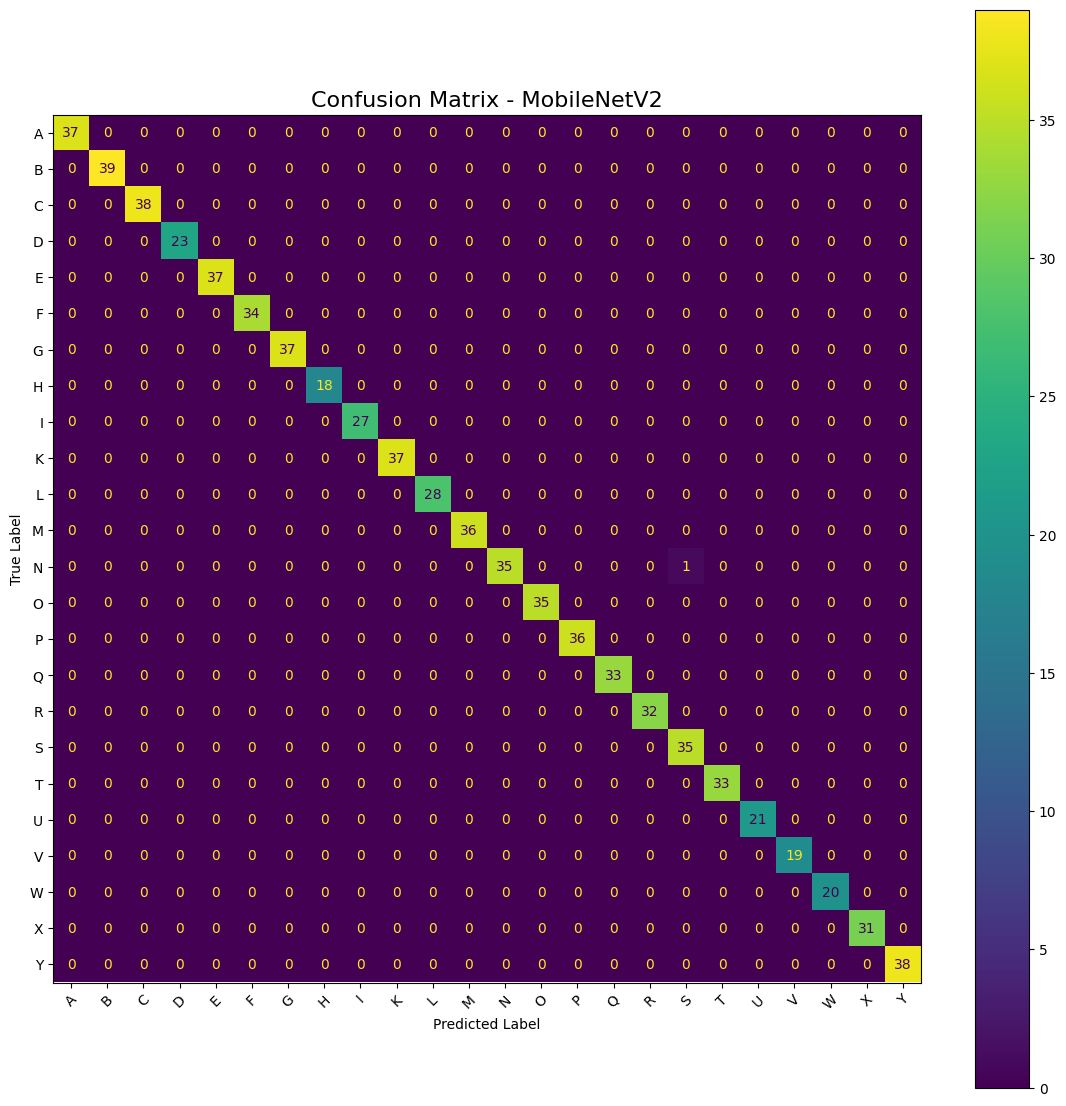

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
mobilenet_cm = confusion_matrix(
    mobilenet_true,
    mobilenet_pred
)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(14, 14))

disp = ConfusionMatrixDisplay(
    confusion_matrix=mobilenet_cm,
    display_labels=mobilenet_class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format='d'
)

plt.title(
    'Confusion Matrix - MobileNetV2',
    fontsize=16
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

### MobileNetV2 Confusion Matrix Analysis

The MobileNetV2 confusion matrix confirms the strong class-level performance observed in the classification report. Out of **760 test images, 759 were correctly classified**, resulting in a test accuracy of approximately **99.87%**.

Almost all predictions lie along the main diagonal of the confusion matrix, indicating correct classification across the 24 ISL classes.

Only **one off-diagonal error** was observed. Among the 36 test images belonging to class **N**, 35 were correctly predicted as N, while **one N image was incorrectly classified as S**.

All remaining 23 classes were correctly classified for every test sample in their respective classes.

This explains the reduced recall of **97.22% for class N** and the reduced precision of **97.22% for class S** observed in the classification report.

Overall, the confusion matrix demonstrates highly consistent performance across the ISL classes, with only one class-level confusion between N and S on the current held-out test set.

# Step 48: Identify the Misclassified Image

In [ ]:
mobilenet_misclassified_indices = np.where(
    mobilenet_pred != mobilenet_true
)[0]

print(
    "Number of misclassified images:",
    len(mobilenet_misclassified_indices)
)

print(
    "Misclassified indices:",
    mobilenet_misclassified_indices
)

Number of misclassified images: 1
Misclassified indices: [403]


### Misclassification Identification Analysis

The prediction results of MobileNetV2 were compared with the actual labels of all **760 test images** to identify individual classification errors.

Only **one test image was misclassified**, corresponding to test-generator index **403**. Therefore, MobileNetV2 correctly classified **759 out of 760 test images**, which is consistent with the observed test accuracy of approximately **99.87%**.

The index value 403 represents the position of the misclassified sample within the ordered test data and does not necessarily correspond to the image filename.

From the confusion matrix, this single error was identified as an actual **N** sample that was predicted as **S**.

The next step examines this specific image together with the model's prediction confidence to better understand the observed classification error.

# Step 49 — Visualize and Analyze the Misclassified Image

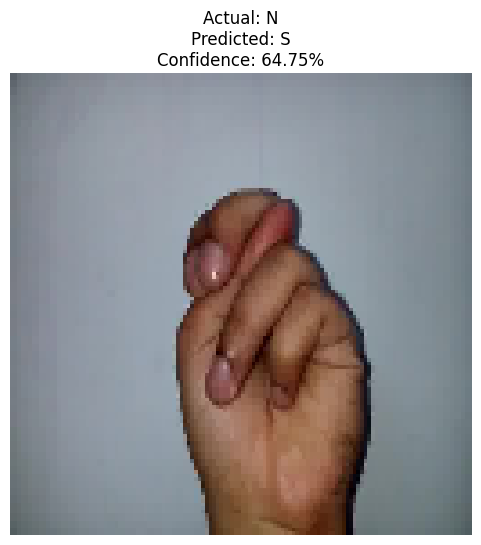

Test index: 403
Image path: /content/drive/MyDrive/ISL_Project/ISL_Clean_Split/test/N/114.jpg
Actual class: N
Predicted class: S
Prediction confidence: 64.75%


In [ ]:
from tensorflow.keras.utils import load_img
import matplotlib.pyplot as plt

# Convert numerical class indices back to class names
index_to_class = {
    v: k
    for k, v in mobilenet_test_data.class_indices.items()
}

# Select the single misclassified image
idx = mobilenet_misclassified_indices[0]

# Get its actual file path
image_path = mobilenet_test_data.filepaths[idx]

# Load the image for visualization
img = load_img(
    image_path,
    target_size=(128, 128)
)

# Get actual class
actual_class = index_to_class[
    mobilenet_true[idx]
]

# Get predicted class
predicted_class = index_to_class[
    mobilenet_pred[idx]
]

# Get prediction confidence
confidence = (
    mobilenet_prob[idx][mobilenet_pred[idx]] * 100
)

# Display the image
plt.figure(figsize=(6, 6))

plt.imshow(img)

plt.title(
    f"Actual: {actual_class}\n"
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")

plt.show()

# Print complete information
print("Test index:", idx)
print("Image path:", image_path)
print("Actual class:", actual_class)
print("Predicted class:", predicted_class)
print(f"Prediction confidence: {confidence:.2f}%")

### MobileNetV2 Misclassification Error Analysis

Detailed error analysis showed that MobileNetV2 misclassified only **one of the 760 test images**.

The misclassified sample was located at test index **403** and belonged to class **N** (`N/114.jpg`). The model incorrectly predicted this image as class **S** with a confidence score of **64.75%**.

The moderate confidence score suggests that this sample was comparatively ambiguous for the trained classifier rather than representing an extremely high-confidence incorrect prediction.

Importantly, this isolated error should not be interpreted as a general inability of MobileNetV2 to recognize class N. The model correctly classified **35 of the 36 N test images**, corresponding to a recall of **97.22%** for class N.

The error may be associated with characteristics of this particular sample, such as hand pose, finger configuration, orientation, or other image-specific visual features. However, a single misclassified image is insufficient to establish the exact cause of the error.

Overall, the error analysis supports the strong internal performance of MobileNetV2, with **759 correct predictions out of 760 test images**. Further testing on externally captured images is required to determine whether this performance generalizes to real-world variations.

# Step 50 — Save the Final MobileNetV2 Model

In [ ]:
final_mobilenet_path = (
    "/content/drive/MyDrive/ISL_Project/"
    "final_mobilenetv2_clean_run.keras"
)

mobilenet_model.save(final_mobilenet_path)

print("Final MobileNetV2 model saved successfully!")
print("Saved at:", final_mobilenet_path)

Final MobileNetV2 model saved successfully!
Saved at: /content/drive/MyDrive/ISL_Project/final_mobilenetv2_clean_run.keras


### Final MobileNetV2 Model Saving

After completing training and internal test evaluation, the trained MobileNetV2 model was saved to Google Drive in Keras format.

Saving the model preserves the learned architecture and weights so that the trained classifier can be reloaded later without repeating the complete training process.

A separate filename was used for the current clean experimental run to preserve previous model versions and maintain reproducibility between experiments.

# Step 51: Final Model Comparison

# Final Model Comparison: Clean Baseline CNN vs MobileNetV2

To identify the more suitable model for Indian Sign Language recognition, the Clean Baseline CNN and MobileNetV2 transfer-learning model were compared using the same cleaned 70:15:15 dataset split.

Both models were trained on the same **3,468 training images**, validated on the same **743 validation images**, and evaluated on the same held-out **760-image test set across 24 ISL classes**.

The comparison considers not only overall accuracy, but also validation performance, test loss, class-wise metrics, number of trainable parameters, and observed misclassification behavior.

In [ ]:
comparison_data = {
    "Metric": [
        "Model Approach",
        "Input Size",
        "Number of Classes",
        "Training Images",
        "Validation Images",
        "Test Images",
        "Total Parameters",
        "Trainable Parameters",
        "Non-Trainable Parameters",
        "Best Validation Accuracy",
        "Best Validation Loss",
        "Test Accuracy",
        "Test Loss",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-Score",
        "Weighted F1-Score",
        "Correct Test Predictions",
        "Misclassified Test Images"
    ],

    "Clean Baseline CNN": [
        "CNN trained from scratch",
        "128 × 128 × 3",
        24,
        3468,
        743,
        760,
        3307736,
        3307736,
        0,
        "99.73%",
        "0.0106",
        "99.87%",
        "0.0102",
        "99.89%",
        "99.89%",
        "99.89%",
        "99.87%",
        "759 / 760",
        1
    ],

    "MobileNetV2": [
        "Transfer Learning",
        "128 × 128 × 3",
        24,
        3468,
        743,
        760,
        2425048,
        167064,
        2257984,
        "99.87%",
        "0.0075",
        "99.87%",
        "0.0075",
        "99.88%",
        "99.88%",
        "99.88%",
        "99.87%",
        "759 / 760",
        1
    ]
}

comparison_df = pd.DataFrame(comparison_data)

comparison_df

,Metric,Clean Baseline CNN,MobileNetV2
0,Model Approach,CNN trained from scratch,Transfer Learning
1,Input Size,128 × 128 × 3,128 × 128 × 3
2,Number of Classes,24,24
3,Training Images,3468,3468
4,Validation Images,743,743
5,Test Images,760,760
6,Total Parameters,3307736,2425048
7,Trainable Parameters,3307736,167064
8,Non-Trainable Parameters,0,2257984
9,Best Validation Accuracy,99.73%,99.87%


### Final Model Comparison Analysis

Both the Clean Baseline CNN and MobileNetV2 achieved excellent performance on the same held-out test set.

The Clean Baseline CNN achieved a **test accuracy of 99.87%** with a test loss of **0.0102**, correctly classifying **759 of 760 test images**.

The MobileNetV2 transfer-learning model also achieved a **test accuracy of 99.87%**, correctly classifying **759 of 760 test images**, but achieved a lower test loss of **0.0075**.

The two models therefore demonstrated nearly identical classification accuracy on the internal test set. However, MobileNetV2 required only **167,064 trainable parameters**, compared with **3,307,736 trainable parameters** in the baseline CNN.

This means that the transfer-learning model achieved comparable predictive performance while updating substantially fewer parameters during training.

The best validation accuracy was also slightly higher for MobileNetV2 (**99.87%**) than for the baseline CNN (**99.73%**), while MobileNetV2 achieved a lower best validation loss.

The error patterns differed between the two models. The baseline CNN misclassified one B sample as E, whereas MobileNetV2 misclassified one N sample as S.

Overall, both models demonstrated excellent performance within the current dataset. MobileNetV2 provides an efficiency advantage because it reuses pretrained ImageNet features and requires substantially fewer trainable parameters.

# Step 52: Select the Final Model

## Final Model Selection

Based on the experimental comparison, **MobileNetV2 was selected as the final model** for the current Indian Sign Language recognition task.

Although both the Clean Baseline CNN and MobileNetV2 achieved the same test accuracy of **99.87%**, MobileNetV2 provided several practical advantages.

MobileNetV2 achieved a lower test loss of **0.0075**, compared with **0.0102** for the baseline CNN. It also achieved a slightly higher best validation accuracy and lower validation loss.

Most importantly, the frozen MobileNetV2 transfer-learning model required only **167,064 trainable parameters**, while the baseline CNN required more than **3.3 million trainable parameters**.

Therefore, MobileNetV2 achieved comparable classification performance with substantially fewer trainable parameters by reusing pretrained ImageNet features.

For these reasons, MobileNetV2 was selected as the final model for subsequent external-image testing and real-world generalization analysis.

# Step 53: Important Limitation Before External Testing

## Important Limitation of Internal Test Performance

The internal test results are very strong; however, the training, validation, and testing images originate from the same source dataset.

Therefore, high internal test accuracy does not necessarily guarantee equivalent performance on real-world images captured using different users, camera devices, backgrounds, lighting conditions, distances, hand orientations, or framing.

To assess practical robustness, the selected final model should also be evaluated using independently captured external images that were not part of the original dataset.

# Step 54: External / Unseen Image Testing


The final MobileNetV2 model achieved 99.87% accuracy on the held-out internal test set. However, all training, validation, and test images originated from the same source dataset.

To evaluate real-world generalization, the final model was additionally tested using independently captured hand-sign images that were not included in the original dataset.

This experiment evaluates whether the model can generalize to variations in hand appearance, lighting, background, camera conditions, image framing, orientation, and other real-world factors.

# Step 54.2 — Load the Final Saved MobileNetV2 Model

In [ ]:
from tensorflow.keras.models import load_model

final_mobilenet_path = (
    "/content/drive/MyDrive/ISL_Project/"
    "final_mobilenetv2_model.keras"
)

final_mobilenet_model = load_model(
    final_mobilenet_path
)

print("Final MobileNetV2 model loaded successfully.")

Final MobileNetV2 model loaded successfully.


# Step 54.3 — Define the 24 ISL Class Names

In [ ]:
mobilenet_class_names = [
    'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I',
    'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S',
    'T', 'U', 'V', 'W', 'X', 'Y'
]

print("Number of ISL classes:", len(mobilenet_class_names))
print("Classes:", mobilenet_class_names)

Number of ISL classes: 24
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


# Step 54.4 — Upload Your External Images

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Actual A.jpeg to Actual A.jpeg
Saving Actual B.jpeg to Actual B.jpeg
Saving Actual L.jpeg to Actual L.jpeg
Saving Actual U.jpeg to Actual U.jpeg
Saving Actual V.jpeg to Actual V.jpeg


# Step 54.5 — Verify the Uploaded Files

In [ ]:
uploaded_files = list(uploaded.keys())

print("Number of external images uploaded:", len(uploaded_files))

print("\nUploaded files:")

for filename in uploaded_files:
    print(filename)

Number of external images uploaded: 5

Uploaded files:
Actual A.jpeg
Actual B.jpeg
Actual L.jpeg
Actual U.jpeg
Actual V.jpeg


# Step 54.6: Preprocess and Predict External Images

## Step 54.6: External Image Prediction

The independently captured hand-sign images were resized to 128 × 128 pixels and processed using the MobileNetV2-specific `preprocess_input` function.

Each image was then passed through the saved final MobileNetV2 model.

For every external image, the following information was recorded:

- Actual ISL class
- Predicted ISL class
- Prediction confidence
- Correct/Incorrect status

This evaluation provides a direct assessment of how well the model generalizes beyond the original dataset.

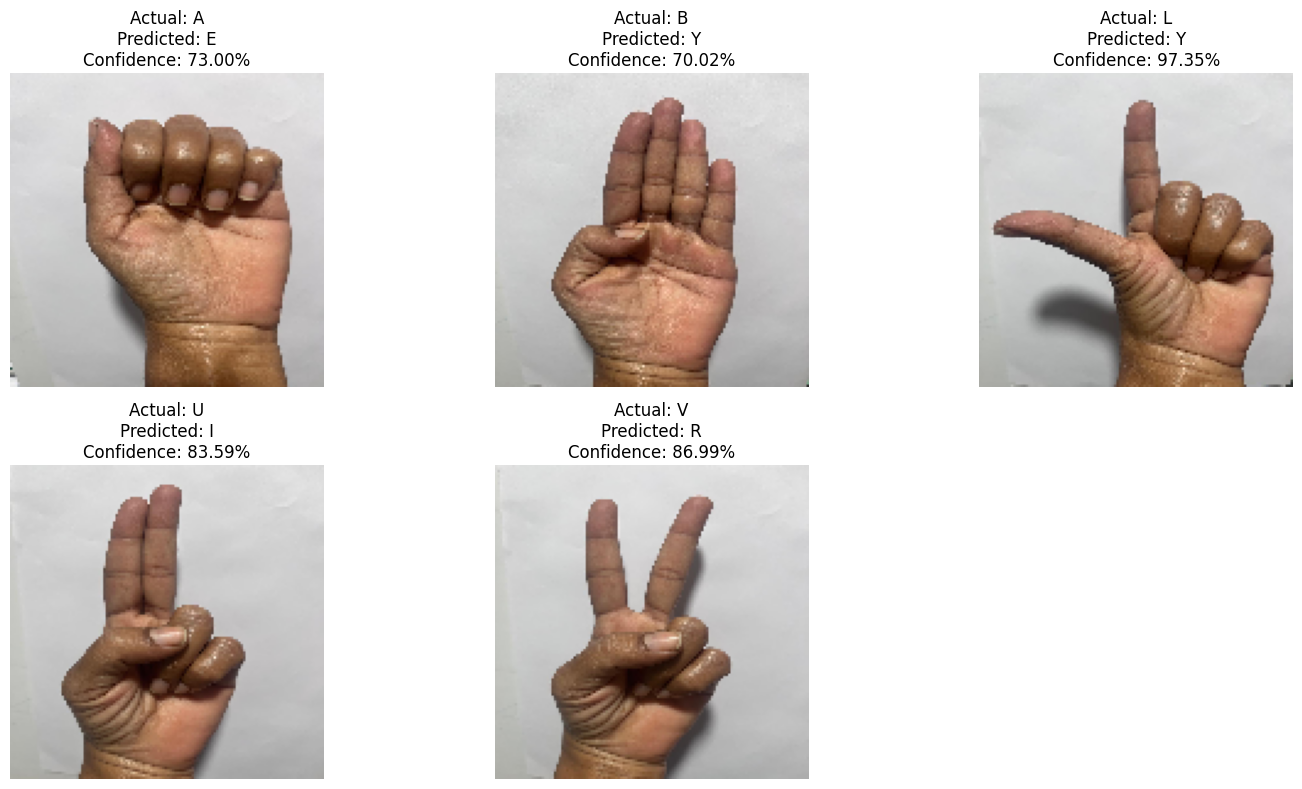

,Filename,Actual Sign,Predicted Sign,Confidence (%),Result
0,Actual A.jpeg,A,E,73.000000,Incorrect
1,Actual B.jpeg,B,Y,70.019997,Incorrect
2,Actual L.jpeg,L,Y,97.349998,Incorrect
3,Actual U.jpeg,U,I,83.589996,Incorrect
4,Actual V.jpeg,V,R,86.989998,Incorrect


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


results = []

plt.figure(figsize=(15, 8))


for i, filename in enumerate(uploaded_files):

    # Extract actual class from filename
    # Example:
    # "Actual A.jpeg" -> "A"
    actual_class = (
        filename
        .replace("Actual ", "")
        .split(".")[0]
    )

    # Load and resize image
    img = load_img(
        filename,
        target_size=(128, 128)
    )

    # Convert image to numerical array
    img_array = img_to_array(img)

    # Add batch dimension
    img_batch = np.expand_dims(
        img_array,
        axis=0
    )

    # Apply MobileNetV2 preprocessing
    img_batch = preprocess_input(
        img_batch
    )

    # Make prediction
    prediction = final_mobilenet_model.predict(
        img_batch,
        verbose=0
    )

    # Predicted class index
    predicted_index = np.argmax(
        prediction[0]
    )

    # Convert index to class name
    predicted_class = mobilenet_class_names[
        predicted_index
    ]

    # Confidence percentage
    confidence = (
        prediction[0][predicted_index] * 100
    )

    # Correct or incorrect
    status = (
        "Correct"
        if predicted_class == actual_class
        else "Incorrect"
    )

    # Store result
    results.append([
        filename,
        actual_class,
        predicted_class,
        round(confidence, 2),
        status
    ])

    # Display image
    plt.subplot(
        2,
        3,
        i + 1
    )

    plt.imshow(img)

    plt.title(
        f"Actual: {actual_class}\n"
        f"Predicted: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )

    plt.axis("off")


plt.tight_layout()
plt.show()


external_results = pd.DataFrame(
    results,
    columns=[
        "Filename",
        "Actual Sign",
        "Predicted Sign",
        "Confidence (%)",
        "Result"
    ]
)

external_results

### External / Unseen Image Testing Analysis

The final MobileNetV2 model was evaluated using five independently captured hand-sign images representing classes A, B, L, U, and V.

Although the model achieved **99.87% accuracy on the internal held-out test set**, it did not correctly classify any of the five externally captured images.

The observed predictions were:

- Actual A → Predicted E (73.00% confidence)
- Actual B → Predicted Y (70.02% confidence)
- Actual L → Predicted Y (97.35% confidence)
- Actual U → Predicted I (83.59% confidence)
- Actual V → Predicted R (86.99% confidence)

Thus, the external evaluation produced **0 correct predictions out of 5 images**.

This large difference between internal and external performance indicates a substantial **generalization gap**. The most likely explanation is domain shift between the original dataset and the independently captured images. Possible differences include hand appearance, finger orientation, camera distance, image framing, lighting, shadows, background characteristics, and other acquisition conditions.

The relatively high confidence values of several incorrect predictions show that the model was not merely uncertain; instead, it had learned decision patterns that transferred poorly to the new image conditions.

Therefore, the internal test accuracy should be interpreted as strong performance on unseen samples from the same dataset distribution, rather than as evidence of reliable real-world performance.

The external experiment highlights the need for a more diverse training dataset containing multiple users, hand appearances, backgrounds, lighting conditions, camera devices, viewing angles, and gesture variations.

# Step 54.7: Quantify the External Result

In [ ]:
external_total = len(external_results)

external_correct = (
    external_results["Result"] == "Correct"
).sum()

external_accuracy = (
    external_correct / external_total
) * 100

print("External Images Tested:", external_total)
print("Correct Predictions:", external_correct)
print(
    "Incorrect Predictions:",
    external_total - external_correct
)
print(
    "External Accuracy (%):",
    external_accuracy
)

External Images Tested: 5
Correct Predictions: 0
Incorrect Predictions: 5
External Accuracy (%): 0.0


# Step 55 — Compare Internal and External Generalization

# Step 55: Internal vs External Generalization Analysis

Although MobileNetV2 achieved excellent performance on the held-out internal test set, external testing revealed substantially weaker performance on independently captured images.

To investigate this difference, internal and external evaluation results were compared. This analysis helps determine whether the model has learned features that generalize beyond the image distribution represented in the original dataset.

In [ ]:
import pandas as pd

generalization_comparison = pd.DataFrame({

    "Evaluation Set": [
        "Internal Test Set",
        "External Pilot Set"
    ],

    "Number of Images": [
        760,
        external_total
    ],

    "Correct Predictions": [
        759,
        external_correct
    ],

    "Incorrect Predictions": [
        1,
        external_total - external_correct
    ],

    "Accuracy (%)": [
        mobilenet_test_accuracy * 100,
        external_accuracy
    ]
})

generalization_comparison

,Evaluation Set,Number of Images,Correct Predictions,Incorrect Predictions,Accuracy (%)
0,Internal Test Set,760,759,1,99.868423
1,External Pilot Set,5,0,5,0.000000


# Step 55.2 — Calculate the Observed Accuracy Gap

In [ ]:
internal_accuracy = mobilenet_test_accuracy * 100

observed_accuracy_gap = (
    internal_accuracy - external_accuracy
)

print(
    "Internal Test Accuracy (%):",
    round(internal_accuracy, 2)
)

print(
    "External Pilot Accuracy (%):",
    round(external_accuracy, 2)
)

print(
    "Observed Accuracy Gap (percentage points):",
    round(observed_accuracy_gap, 2)
)

Internal Test Accuracy (%): 99.87
External Pilot Accuracy (%): 0.0
Observed Accuracy Gap (percentage points): 99.87


# Step 55.3 — Visualize Internal vs External Performance

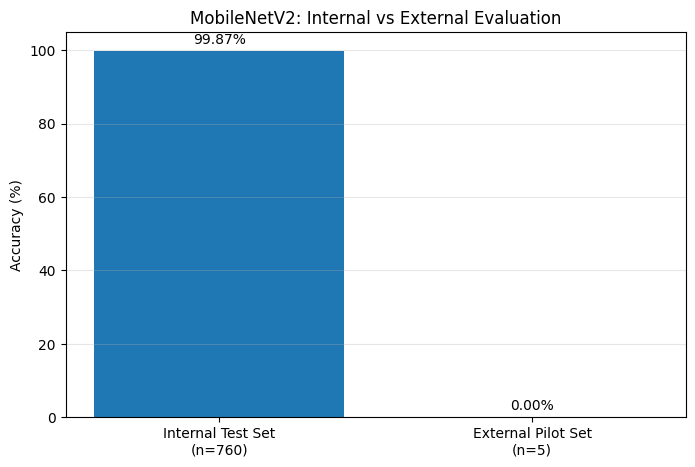

In [ ]:
import matplotlib.pyplot as plt

labels = [
    "Internal Test Set\n(n=760)",
    "External Pilot Set\n(n=5)"
]

accuracies = [
    internal_accuracy,
    external_accuracy
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    labels,
    accuracies
)

plt.ylabel("Accuracy (%)")

plt.title(
    "MobileNetV2: Internal vs External Evaluation"
)

plt.ylim(0, 105)

for bar, value in zip(bars, accuracies):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 2,
        f"{value:.2f}%",
        ha="center"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

### Internal vs External Generalization Analysis

The final MobileNetV2 model demonstrated substantially different performance across the two evaluation settings.

On the held-out internal test set, the model correctly classified **759 of 760 images**, achieving an accuracy of approximately **99.87%**. In contrast, none of the **five independently captured external images** were correctly classified during the preliminary external evaluation.

This produced an observed accuracy difference of approximately **99.87 percentage points** between the internal and external evaluations.

The result should be interpreted cautiously because the external pilot set contains only five images and therefore cannot provide a statistically reliable estimate of real-world model accuracy. Nevertheless, the consistent failure across these independently captured samples provides evidence of a substantial **domain-shift/generalization issue**.

The original training, validation, and internal test images originate from the same source dataset and therefore likely share characteristics such as image acquisition conditions, background, hand positioning, lighting, scale, and framing. Independently captured images introduce variations in these characteristics that were not sufficiently represented during model training.

Furthermore, several incorrect external predictions were associated with relatively high softmax confidence values. This demonstrates that high model confidence does not necessarily imply prediction correctness, particularly for samples outside the training distribution.

Therefore, while MobileNetV2 provides excellent **in-distribution performance**, additional data diversity and external validation are required before the model can be considered reliable for real-world ISL recognition.

# Step 56: Final Model Comparison

# Step 56: Final Model Comparison

The Clean Baseline CNN and MobileNetV2 transfer-learning model were evaluated using the same cleaned train-validation-test split.

| Metric                    |       Clean Baseline CNN |       MobileNetV2 |
| ------------------------- | -----------------------: | ----------------: |
| Training Approach         | CNN trained from scratch | Transfer Learning |
| Training Images           |                    3,468 |             3,468 |
| Validation Images         |                      743 |               743 |
| Test Images               |                      760 |               760 |
| Best Validation Accuracy  |                   99.73% |        **99.87%** |
| Best Validation Loss      |                   0.0106 |        **0.0075** |
| Test Accuracy             |               **99.87%** |        **99.87%** |
| Test Loss                 |                   0.0102 |        **0.0075** |
| Correct Test Predictions  |                759 / 760 |         759 / 760 |
| Misclassified Test Images |                        1 |                 1 |
| Baseline Error            |                    B → E |                 — |
| MobileNetV2 Error         |                        — |             N → S |
| Total Parameters          |                3,307,736 |         2,425,048 |
| Trainable Parameters      |                3,307,736 |       **167,064** |
| Pretrained Weights        |                       No |          ImageNet |

### Comparison Analysis

Both models achieved excellent performance on the held-out internal test set, with a test accuracy of **99.87%** and 759 correct predictions out of 760 images.

The Clean Baseline CNN achieved a test loss of **0.0102**, while MobileNetV2 achieved a lower test loss of **0.0075**.

The baseline CNN was trained completely from scratch and required **3,307,736 trainable parameters**. In contrast, the frozen MobileNetV2 transfer-learning model required only **167,064 trainable parameters**, while the pretrained convolutional feature extractor remained frozen.

The best validation accuracy was also slightly higher for MobileNetV2 at **99.87%**, compared with **99.73%** for the baseline CNN.

The error patterns differed between the models. The baseline CNN misclassified one B image as E, whereas MobileNetV2 misclassified one N image as S.

### Final Model Selection

Although both models achieved the same internal test accuracy, **MobileNetV2 was selected as the final model** because it achieved:

* Lower test loss.
* Slightly higher best validation accuracy.
* Lower best validation loss.
* Comparable test performance with substantially fewer trainable parameters.
* Efficient reuse of pretrained visual features learned from ImageNet.

Therefore, MobileNetV2 provided the best balance between predictive performance and training efficiency for the current ISL dataset.


# Step 57: Final Conclusion, Limitations, and Future Scope

# Step 57: Final Conclusion, Limitations, and Future Scope

## Final Conclusion

This project developed and evaluated deep-learning models for recognizing **24 static Indian Sign Language classes**.

Before model development, the dataset was systematically analyzed for class distribution, image dimensions, data quality, and duplicate images. One exact duplicate was detected and removed, resulting in a cleaned dataset containing **4,971 unique images**.

The cleaned dataset was divided into approximately **70:15:15 training, validation, and testing subsets**, containing:

* Training: **3,468 images**
* Validation: **743 images**
* Testing: **760 images**

Exact duplicate verification was subsequently performed across the final subsets, and **zero exact duplicate overlap** was detected between training, validation, and testing data.

A custom baseline CNN was first trained from scratch. The clean baseline CNN achieved **99.87% test accuracy**, with only one misclassified test image.

Transfer learning was then implemented using MobileNetV2 pretrained on ImageNet. The pretrained convolutional base was frozen and used as a feature extractor, while new classification layers were trained for the 24 ISL classes.

MobileNetV2 also achieved **99.87% test accuracy**, with a lower test loss of **0.0075** and only **167,064 trainable parameters**, compared with more than 3.3 million trainable parameters in the baseline CNN.

Based on its lower loss, slightly stronger validation performance, and greater parameter efficiency, **MobileNetV2 was selected as the final model**.

### External Generalization Finding

The project additionally evaluated the selected MobileNetV2 model using five independently captured hand-sign images representing A, B, L, U, and V.

Although MobileNetV2 achieved **99.87% accuracy on the internal test set**, none of the five external pilot images were correctly classified.

The external results were:

* A → E
* B → Y
* L → Y
* U → I
* V → R

This substantial difference between internal and external performance indicates a **generalization gap caused by domain shift**.

The result suggests that excellent performance on a held-out subset from the same source dataset does not necessarily guarantee reliable performance on independently captured real-world images.

Because only five external images were evaluated, this result should be interpreted as a **preliminary external generalization check**, rather than as a statistically reliable estimate of real-world accuracy.

## Limitations

The major limitations of the current project are:

1. Training, validation, and internal test images originate from the same source dataset.
2. The dataset may not contain sufficient diversity in users, hand appearance, lighting conditions, backgrounds, camera devices, distances, and orientations.
3. Only five independently captured images were used for external testing.
4. The current system recognizes static hand-sign images rather than continuous sign-language video.
5. Exact MD5 hashing detects identical files but does not guarantee the absence of visually similar near-duplicate images.
6. The current model is limited to the 24 static ISL classes available in the dataset.

## Future Scope

Future work should focus on improving real-world robustness by:

1. Collecting images from multiple users.
2. Increasing variation in skin appearance, hand size, and gesture execution.
3. Including different backgrounds and lighting conditions.
4. Capturing images using different cameras and mobile devices.
5. Increasing variation in distance, scale, orientation, and image framing.
6. Creating a substantially larger independent external test set.
7. Exploring stronger but sign-preserving data augmentation.
8. Fine-tuning selected MobileNetV2 layers using a more diverse dataset.
9. Investigating hand-detection or hand-region extraction before classification.
10. Extending the model to real-time webcam-based ISL recognition.
11. Exploring sequence-based deep-learning approaches for dynamic signs and continuous sign-language recognition.

## Final Project Finding

The most important finding of this project is that **high internal test accuracy alone is not sufficient evidence of real-world generalization**.

The model performed extremely well on unseen images from the original dataset distribution but showed poor performance on a small external set captured under different conditions.

Therefore, rigorous data-quality analysis, leakage verification, class-level evaluation, error analysis, and external validation are essential before considering an image-classification model ready for real-world deployment.

**End of Project**
